#Анализ пролонгаций договоров

In [1]:
# from google.colab import files
# uploaded = files.upload()

PATH_PROL = 'prolongations.csv'
PATH_FIN  = 'financial_data.csv'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

## 1. Загрузка и первичный осмотр данных

In [2]:
prol_raw = pd.read_csv(PATH_PROL)
fin_raw  = pd.read_csv(PATH_FIN)

print('prolongations.csv')
print(f'Строк: {len(prol_raw)}, Столбцов: {len(prol_raw.columns)}')
display(prol_raw.head())

print('\nfinancial_data.csv')
print(f'Строк: {len(fin_raw)}, Столбцов: {len(fin_raw.columns)}')
display(fin_raw.head())

prolongations.csv
Строк: 477, Столбцов: 3


,id,month,AM
0,42,ноябрь 2022,Васильев Артем Александрович
1,453,ноябрь 2022,Васильев Артем Александрович
2,548,ноябрь 2022,Михайлов Андрей Сергеевич
3,87,ноябрь 2022,Соколова Анастасия Викторовна
4,429,ноябрь 2022,Соколова Анастасия Викторовна



financial_data.csv
Строк: 451, Столбцов: 19


,id,Причина дубля,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024,Account
0,42,NaN,"36 220,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
1,657,первая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
2,657,вторая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
3,594,NaN,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
4,665,NaN,"10 000,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович


In [3]:
# Уникальные значения и распределение по менеджерам
print('Менеджеры в prolongations.csv:')
print(prol_raw['AM'].value_counts().to_string())

print('\nПоследние месяцы проектов:')
print(prol_raw['month'].value_counts().sort_index().to_string())

Менеджеры в prolongations.csv:
AM
Васильев Артем Александрович     139
Соколова Анастасия Викторовна     86
Попова Екатерина Николаевна       76
Смирнова Ольга Владимировна       69
Иванова Мария Сергеевна           48
Михайлов Андрей Сергеевич         31
Кузнецов Михаил Иванович          23
без А/М                            2
Федорова Марина Васильевна         2
Петрова Анна Дмитриевна            1

Последние месяцы проектов:
month
август 2023      26
апрель 2023      28
декабрь 2022     67
декабрь 2023     69
июль 2023        23
июнь 2023        31
май 2023         22
март 2023        33
ноябрь 2022      24
ноябрь 2023      40
октябрь 2023     24
сентябрь 2023    42
февраль 2023     28
январь 2023      20


In [4]:
# Причины дублей в financial_data
print('Причины дублей строк:')
print(fin_raw['Причина дубля'].value_counts(dropna=False).to_string())

print(f'\nУникальных id в financial_data: {fin_raw["id"].nunique()}')
print(f'Всего строк: {len(fin_raw)}')
print(f'Дубли id: {fin_raw[fin_raw.duplicated("id", keep=False)]["id"].nunique()}')

Причины дублей строк:
Причина дубля
NaN                    150
первая часть оплаты    114
вторая часть оплаты     99
доп работы              38
основные работы         38
изменение ЮЛ            11
карты, банки             1

Уникальных id в financial_data: 314
Всего строк: 451
Дубли id: 123


In [5]:
# Специальные строковые значения в ячейках отгрузки
month_cols = [c for c in fin_raw.columns if c not in ('id', 'Причина дубля', 'Account')]

special_vals = set()
for col in month_cols:
    for v in fin_raw[col].dropna().astype(str):
        cleaned = v.replace('\xa0','').replace(',','.').replace(' ','').strip()
        try:
            float(cleaned)
        except:
            special_vals.add(v.strip())

print(f'\nСпециальные нечисловые значения: {special_vals}')
print('''
  "стоп" / "end" исключаем из расчёта
  "в ноль" нужно взять предыдущий ненулевой месяц
''')


Специальные нечисловые значения: {'end', 'в ноль', 'стоп'}

  "стоп" / "end" исключаем из расчёта
  "в ноль" нужно взять предыдущий ненулевой месяц



## 2. Очистка и подготовка данных

### 2.1 Парсинг значений отгрузки

In [6]:
COL_MONTHS = [
    'Ноябрь 2022','Декабрь 2022',
    'Январь 2023','Февраль 2023','Март 2023','Апрель 2023',
    'Май 2023','Июнь 2023','Июль 2023','Август 2023',
    'Сентябрь 2023','Октябрь 2023','Ноябрь 2023','Декабрь 2023',
    'Январь 2024','Февраль 2024'
]
COL_IDX   = {c: i for i, c in enumerate(COL_MONTHS)}
LOWER_TO_COL = {c.lower(): c for c in COL_MONTHS}
MONTHS_2023  = COL_MONTHS[2:14]  # Январь–Декабрь 2023


def parse_val(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().replace('\xa0','').replace(' ','').replace(',','.')
    if s in ('стоп', 'end'):
        return 'стоп'
    if s == 'вноль':
        return 'вноль'
    try:
        return float(s)
    except:
        return np.nan


fin = fin_raw.copy()
for col in COL_MONTHS:
    fin[col] = fin[col].apply(parse_val)

display(fin[['id','Причина дубля','Ноябрь 2022','Декабрь 2022','Январь 2023']].head(6))

,id,Причина дубля,Ноябрь 2022,Декабрь 2022,Январь 2023
0,42,NaN,36220.0,NaN,NaN
1,657,первая часть оплаты,стоп,NaN,NaN
2,657,вторая часть оплаты,стоп,NaN,NaN
3,594,NaN,стоп,NaN,NaN
4,665,NaN,10000.0,NaN,NaN
5,637,NaN,38045.0,NaN,NaN


### 2.2 Агрегация дублей по id

Одному проекту может соответствовать несколько строк (разные части оплаты, изменение ЮЛ и т.д.).

**Правила агрегации:**
- Если хотя бы одна часть имеет `'стоп'` или `'end'` — весь месяц помечается как `'стоп'`
- Числовые значения суммируются
- Если чисел нет, но есть `'вноль'` — ставим `'вноль'`
- Иначе — `NaN`

In [7]:
def aggregate_by_id(group):
    result = {}
    for col in COL_MONTHS:
        vals = group[col].tolist()
        if any(v == 'стоп' for v in vals):
            result[col] = 'стоп'
        else:
            nums = [v for v in vals if isinstance(v, float) and not np.isnan(v)]
            if nums:
                result[col] = sum(nums)
            elif any(v == 'вноль' for v in vals):
                result[col] = 'вноль'
            else:
                result[col] = np.nan
    return pd.Series(result)


fin_agg = fin.groupby('id').apply(aggregate_by_id).reset_index()

print(f'До:  {len(fin)} строк')
print(f'После: {len(fin_agg)}')
display(fin_agg.head(4))

До:  451 строк
После: 314


,id,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024
0,15,439280.0,439280.0,102433.75,102433.75,102433.75,138158.0,138158.0,102433.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,31,55100.0,55100.0,NaN,44775.0,44775.0,44775.0,44775.0,44775.0,44775.0,44775.0,44775.0,44775.0,44775.0,44775.0,44775.0,46200.0
3,39,137700.0,137700.0,149206.5,149206.5,149206.5,149206.5,149206.5,149206.5,149206.5,149206.5,149206.5,149206.5,149206.5,149206.5,NaN,NaN


### 2.3 Объединение с таблицей пролонгаций

АМ берём из `prolongations.csv` — эти данные первичны.

In [8]:
prol = prol_raw.copy()
prol['month_lower'] = prol['month'].str.lower().str.strip()

merged = prol.merge(fin_agg, on='id', how='left')
print(f'Итого записей после merge: {len(merged)}')
print(f'Проектов без финансовых данных: {merged[COL_MONTHS[0]].isna().sum()}')
display(merged[['id','month','AM','Ноябрь 2022','Декабрь 2022','Январь 2023']].head())

Итого записей после merge: 477
Проектов без финансовых данных: 262


,id,month,AM,Ноябрь 2022,Декабрь 2022,Январь 2023
0,42,ноябрь 2022,Васильев Артем Александрович,36220.0,NaN,NaN
1,453,ноябрь 2022,Васильев Артем Александрович,вноль,39245.0,44320.0
2,548,ноябрь 2022,Михайлов Андрей Сергеевич,674000.0,674000.0,674000.0
3,87,ноябрь 2022,Соколова Анастасия Викторовна,70050.0,NaN,73380.0
4,429,ноябрь 2022,Соколова Анастасия Викторовна,30280.0,35580.0,35830.0


### 2.4 Вспомогательные функции

Три базовых операции, которые используются во всех дальнейших расчётах.

1. Возвращает числовое значение отгрузки в заданном месяце

Если значение 'вноль' — ищем ближайший предыдущий месяц с числом.
'в ноль' означает нулевую отгрузку в этом месяце, и по ТЗ нужно использовать предыдущий ненулевой месяц

2.  Проверяет, есть ли у проекта статус 'стоп'/'end' в последнем месяце реализации или ранее. Эти проекты полностью исключаются из расчёта пролонгаций

3. Проверяет, что у проекта нет отгрузки в заданном месяце.
Используется для фильтрации базы К2 (не пролонгированные в M-1)

In [10]:
def get_numeric(row, col):
    val = row.get(col, np.nan)
    if isinstance(val, float) and not np.isnan(val):
        return val
    if val == 'вноль':
        idx = COL_IDX[col]
        for i in range(idx - 1, -1, -1):
            v = row.get(COL_MONTHS[i], np.nan)
            if isinstance(v, float) and not np.isnan(v):
                return v
    return np.nan


def is_stopped(row, last_col):
    last_idx = COL_IDX[last_col]
    for i in range(0, last_idx + 1):
        if row.get(COL_MONTHS[i]) == 'стоп':
            return True
    return False


def no_ship_in(row, col):
    v = get_numeric(row, col)
    return not (isinstance(v, float) and not np.isnan(v) and v > 0)


# Подготовка финального датасета
merged['last_col'] = merged['month_lower'].map(LOWER_TO_COL)

merged['is_stopped'] = merged.apply(
    lambda r: is_stopped(r, r['last_col']) if r['last_col'] else True, axis=1
)
merged['last_shipment'] = merged.apply(
    lambda r: get_numeric(r, r['last_col']) if r['last_col'] else np.nan, axis=1
)

valid = merged[~merged['is_stopped'] & merged['last_shipment'].notna()].copy()

print(f'Всего проектов: {len(merged)}')
print(f'Исключено: {merged["is_stopped"].sum()}')
print(f'Нет фин. данных: {merged["last_shipment"].isna().sum() - merged["is_stopped"].sum()}')
print(f'Валидных проектов: {len(valid)}')

Всего проектов: 477
Исключено: 48
Нет фин. данных: 26
Валидных проектов: 402


## 3. Логика расчёта коэффициентов

### Коэффициент К1 (пролонгация в 1ый месяц)

Для расчёта за месяц **M**:
```
Знаменатель = Σ отгрузка[M-1] по проектам, завершившимся в M-1
Числитель   = Σ отгрузка[M]   по тем же проектам, у которых есть отгрузка в M

К1 = Числитель / Знаменатель
```

### Коэффициент К2 (пролонгация во 2ой месяц)
Для расчёта за месяц **M**:
```
База        = проекты, завершившиеся в M-2 И не имеющие отгрузки в M-1
Знаменатель = Σ отгрузка[M-2] по проектам базы
Числитель   = Σ отгрузка[M]   по проектам базы, у которых есть отгрузка в M

К2 = Числитель / Знаменатель
```


## 4. Расчёт коэффициентов

In [11]:
#Рассчитывает К1 и К2 для заданного месяца и заданного набора проектов
#Возвращает словарь с К1, К2 и компонентами для проверки.
def compute_coeff(df, calc_month):
    calc_idx = COL_IDX[calc_month]
    if calc_idx < 1:
        return None

    prev1_col = COL_MONTHS[calc_idx - 1]  # M-1
    prev2_col = COL_MONTHS[calc_idx - 2] if calc_idx >= 2 else None  # M-2

    #К1
    c1_base  = df[df['last_col'] == prev1_col]
    c1_denom = c1_base['last_shipment'].sum()
    c1_numer = sum(
        v for v in c1_base.apply(lambda r: get_numeric(r, calc_month), axis=1)
        if isinstance(v, float) and not np.isnan(v)
    )
    coeff1 = c1_numer / c1_denom if c1_denom > 0 else np.nan

    #К2
    if prev2_col:
        c2_base  = df[
            (df['last_col'] == prev2_col) &
            df.apply(lambda r: no_ship_in(r, prev1_col), axis=1)
        ]
        c2_denom = c2_base['last_shipment'].sum()
        c2_numer = sum(
            v for v in c2_base.apply(lambda r: get_numeric(r, calc_month), axis=1)
            if isinstance(v, float) and not np.isnan(v)
        )
        coeff2 = c2_numer / c2_denom if c2_denom > 0 else np.nan
    else:
        c2_base = pd.DataFrame()
        c2_denom = c2_numer = 0
        coeff2 = np.nan

    return {
        'coeff1': coeff1, 'c1_numer': c1_numer, 'c1_denom': c1_denom, 'c1_n': len(c1_base),
        'coeff2': coeff2, 'c2_numer': c2_numer, 'c2_denom': c2_denom, 'c2_n': len(c2_base)
    }

#Годовой коэффициент
def compute_annual(df):
    c1_n = c1_d = c2_n = c2_d = 0
    for m in MONTHS_2023:
        r = compute_coeff(df, m)
        if r:
            c1_n += r['c1_numer']; c1_d += r['c1_denom']
            c2_n += r['c2_numer']; c2_d += r['c2_denom']
    return {
        'coeff1': c1_n / c1_d if c1_d > 0 else np.nan,
        'coeff2': c2_n / c2_d if c2_d > 0 else np.nan,
        'c1_numer': c1_n, 'c1_denom': c1_d,
        'c2_numer': c2_n, 'c2_denom': c2_d
    }


In [12]:
# Список менеджеров без а/м
managers = sorted([m for m in valid['AM'].unique() if m != 'без А/М'])
all_entities = ['Отдел в целом'] + managers

# Расчёт по всем месяцам и менеджерам
results = {}
for m in MONTHS_2023:
    results[m] = {}
    results[m]['Отдел в целом'] = compute_coeff(valid, m)
    for mgr in managers:
        sub = valid[valid['AM'] == mgr]
        results[m][mgr] = compute_coeff(sub, m)

# Годовые коэффициенты
annual = {'Отдел в целом': compute_annual(valid)}
for mgr in managers:
    annual[mgr] = compute_annual(valid[valid['AM'] == mgr])

print(f'Менеджеров: {len(managers)}, месяцев: {len(MONTHS_2023)}')

Менеджеров: 9, месяцев: 12


## 5. Результаты

In [13]:
# Сводная таблица К1
short_months = ['Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт','Ноя','Дек']

rows_k1 = []
for entity in all_entities:
    row = {'Менеджер': entity}
    for i, m in enumerate(MONTHS_2023):
        r = results[m].get(entity)
        row[short_months[i]] = r['coeff1'] if r else np.nan
    row['Год'] = annual[entity]['coeff1']
    rows_k1.append(row)

df_k1 = pd.DataFrame(rows_k1).set_index('Менеджер')

print('К1')
display(df_k1.style
    .format(lambda x: f'{x:.1%}' if isinstance(x, float) and not np.isnan(x) else '—')
    .background_gradient(cmap='RdYlGn', vmin=0, vmax=1, axis=None)
    .set_properties(**{'font-size': '11px'})
)

К1


,Янв,Фев,Мар,Апр,Май,Июн,Июл,Авг,Сен,Окт,Ноя,Дек,Год
Менеджер,,,,,,,,,,,,,
Отдел в целом,45.9%,78.3%,64.6%,36.1%,56.8%,22.1%,52.4%,48.7%,34.9%,82.8%,51.8%,54.5%,53.5%
Васильев Артем Александрович,59.8%,105.7%,62.7%,35.1%,44.3%,38.9%,58.5%,47.8%,17.2%,88.7%,62.1%,32.4%,51.3%
Иванова Мария Сергеевна,27.0%,—,44.6%,27.8%,100.0%,0.0%,47.3%,54.1%,99.9%,—,—,—,35.1%
Кузнецов Михаил Иванович,126.6%,84.7%,—,0.0%,—,—,—,—,—,130.9%,47.4%,27.4%,47.8%
Михайлов Андрей Сергеевич,68.8%,90.4%,243.1%,109.9%,119.0%,0.0%,119.8%,—,0.0%,44.9%,—,0.0%,66.5%
Петрова Анна Дмитриевна,—,—,—,—,—,—,—,—,—,—,—,111.1%,111.1%
Попова Екатерина Николаевна,44.1%,80.1%,49.6%,9.5%,75.7%,0.0%,8.9%,48.0%,74.7%,79.4%,—,60.0%,51.2%
Смирнова Ольга Владимировна,74.3%,0.0%,—,96.6%,—,0.0%,0.0%,37.3%,76.5%,104.7%,83.6%,36.1%,70.3%
Соколова Анастасия Викторовна,42.7%,23.5%,93.9%,106.6%,23.7%,76.6%,61.9%,54.1%,26.0%,84.2%,17.9%,79.1%,57.9%


In [14]:
# Сводная таблица К2
rows_k2 = []
for entity in all_entities:
    row = {'Менеджер': entity}
    for i, m in enumerate(MONTHS_2023):
        r = results[m].get(entity)
        row[short_months[i]] = r['coeff2'] if r else np.nan
    row['Год'] = annual[entity]['coeff2']
    rows_k2.append(row)

df_k2 = pd.DataFrame(rows_k2).set_index('Менеджер')

print('К2')
display(df_k2.style
    .format(lambda x: f'{x:.1%}' if isinstance(x, float) and not np.isnan(x) else '—')
    .background_gradient(cmap='RdYlGn', vmin=0, vmax=0.4, axis=None)
    .set_properties(**{'font-size': '11px'})
)

К2


,Янв,Фев,Мар,Апр,Май,Июн,Июл,Авг,Сен,Окт,Ноя,Дек,Год
Менеджер,,,,,,,,,,,,,
Отдел в целом,13.5%,5.0%,16.2%,9.2%,0.0%,3.8%,6.8%,3.5%,0.0%,4.0%,1.9%,15.5%,5.0%
Васильев Артем Александрович,0.0%,5.5%,70.8%,11.0%,0.0%,5.7%,0.0%,0.0%,0.0%,7.2%,0.0%,48.5%,6.3%
Иванова Мария Сергеевна,0.0%,0.0%,—,0.0%,0.0%,—,0.0%,0.0%,0.0%,—,—,—,0.0%
Кузнецов Михаил Иванович,—,—,—,—,0.0%,—,—,—,—,—,—,0.0%,0.0%
Михайлов Андрей Сергеевич,0.0%,0.0%,—,—,—,—,0.0%,—,—,0.0%,0.0%,—,0.0%
Петрова Анна Дмитриевна,—,—,—,—,—,—,—,—,—,—,—,—,—
Попова Екатерина Николаевна,0.0%,0.0%,0.0%,19.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,19.0%,—,1.7%
Смирнова Ольга Владимировна,—,0.0%,115.1%,—,—,—,51.6%,155.3%,0.0%,0.0%,0.0%,39.8%,25.4%
Соколова Анастасия Викторовна,67.9%,21.6%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,5.9%


In [15]:
# Годовые показатели с базами
rows_ann = []
for entity in all_entities:
    a = annual[entity]
    rows_ann.append({
        'Менеджер':      entity,
        'К1 (год)':      a['coeff1'],
        'К2 (год)':      a['coeff2'],
        'База К1 (руб.)':     a['c1_denom'],
        'Пролонг К1 (руб.)':  a['c1_numer'],
        'База К2 (руб.)':     a['c2_denom'],
        'Пролонг К2 (руб.)':  a['c2_numer'],
    })

df_ann = pd.DataFrame(rows_ann).set_index('Менеджер')

print('Годовые коэффициенты пролонгации 2023:')
display(df_ann.style
    .format({
        'К1 (год)': lambda x: f'{x:.1%}' if not np.isnan(x) else '—',
        'К2 (год)': lambda x: f'{x:.1%}' if not np.isnan(x) else '—',
        'База К1 (руб.)':    '{:,.0f}',
        'Пролонг К1 (руб.)': '{:,.0f}',
        'База К2 (руб.)':    '{:,.0f}',
        'Пролонг К2 (руб.)': '{:,.0f}',
    })
    .background_gradient(subset=['К1 (год)'], cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['К2 (год)'], cmap='RdYlGn', vmin=0, vmax=0.4)
)

Годовые коэффициенты пролонгации 2023:


,К1 (год),К2 (год),База К1 (руб.),Пролонг К1 (руб.),База К2 (руб.),Пролонг К2 (руб.)
Менеджер,,,,,,
Отдел в целом,53.5%,5.0%,"35,707,592","19,094,990","15,519,318","773,632"
Васильев Артем Александрович,51.3%,6.3%,"11,832,148","6,069,164","5,747,845","360,942"
Иванова Мария Сергеевна,35.1%,0.0%,"4,727,657","1,660,096","2,503,865",0
Кузнецов Михаил Иванович,47.8%,0.0%,"982,724","470,183","167,675",0
Михайлов Андрей Сергеевич,66.5%,0.0%,"3,361,834","2,235,422","1,056,005",0
Петрова Анна Дмитриевна,111.1%,—,"98,492","109,443",0,0
Попова Екатерина Николаевна,51.2%,1.7%,"4,890,598","2,502,851","2,363,545","39,140"
Смирнова Ольга Владимировна,70.3%,25.4%,"2,951,205","2,073,564","803,501","203,825"
Соколова Анастасия Викторовна,57.9%,5.9%,"6,862,934","3,974,268","2,876,882","169,725"


---
## 6. Визуализация

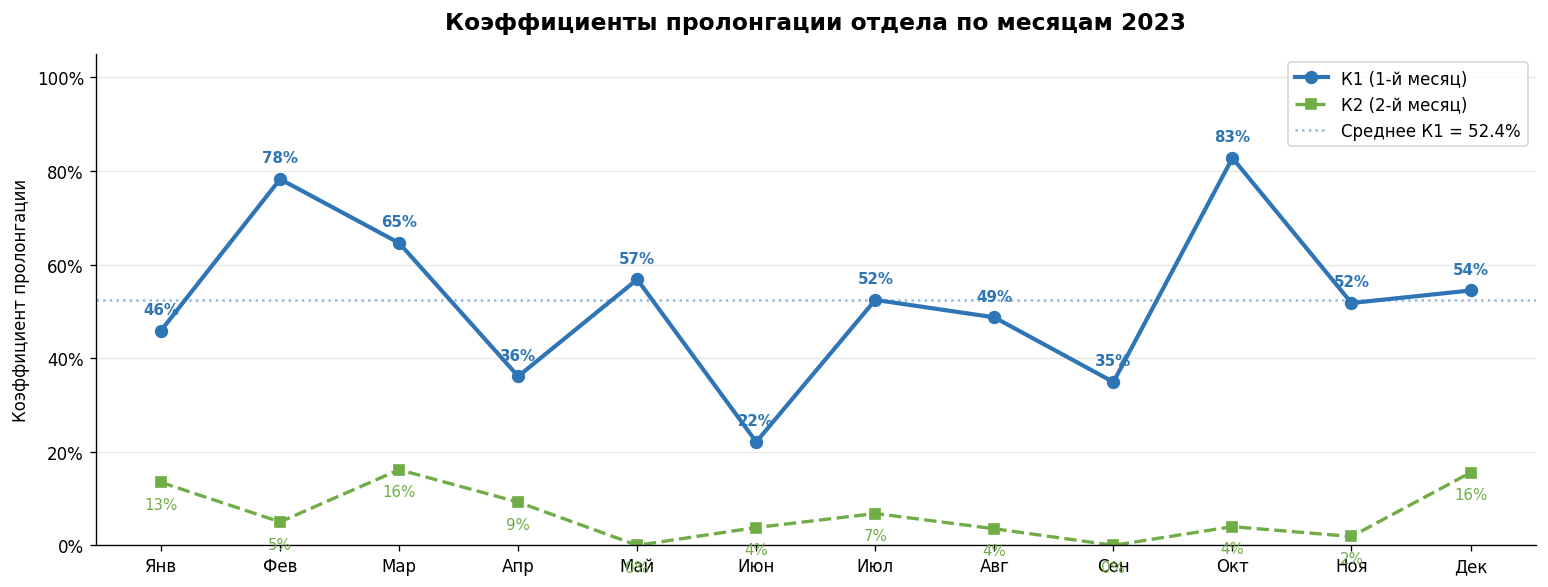

In [16]:
#Динамика К1 и К2 по отделу в целом
dept_k1 = [results[m]['Отдел в целом']['coeff1'] for m in MONTHS_2023]
dept_k2 = [results[m]['Отдел в целом']['coeff2'] for m in MONTHS_2023]

fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(short_months))

ax.plot(x, dept_k1, 'o-', color='#2E75B6', linewidth=2.5, markersize=7, label='К1 (1-й месяц)')
ax.plot(x, dept_k2, 's--', color='#70AD47', linewidth=2, markersize=6, label='К2 (2-й месяц)')

for i, (v1, v2) in enumerate(zip(dept_k1, dept_k2)):
    if not np.isnan(v1):
        ax.annotate(f'{v1:.0%}', (i, v1), textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=9, color='#2E75B6', fontweight='bold')
    if not np.isnan(v2):
        ax.annotate(f'{v2:.0%}', (i, v2), textcoords='offset points', xytext=(0, -16),
                    ha='center', fontsize=9, color='#70AD47')

ax.axhline(np.nanmean(dept_k1), color='#2E75B6', linestyle=':', alpha=0.5, linewidth=1.5,
           label=f'Среднее К1 = {np.nanmean(dept_k1):.1%}')

ax.set_xticks(list(x))
ax.set_xticklabels(short_months)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, 1.05)
ax.set_title('Коэффициенты пролонгации отдела по месяцам 2023', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Коэффициент пролонгации')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

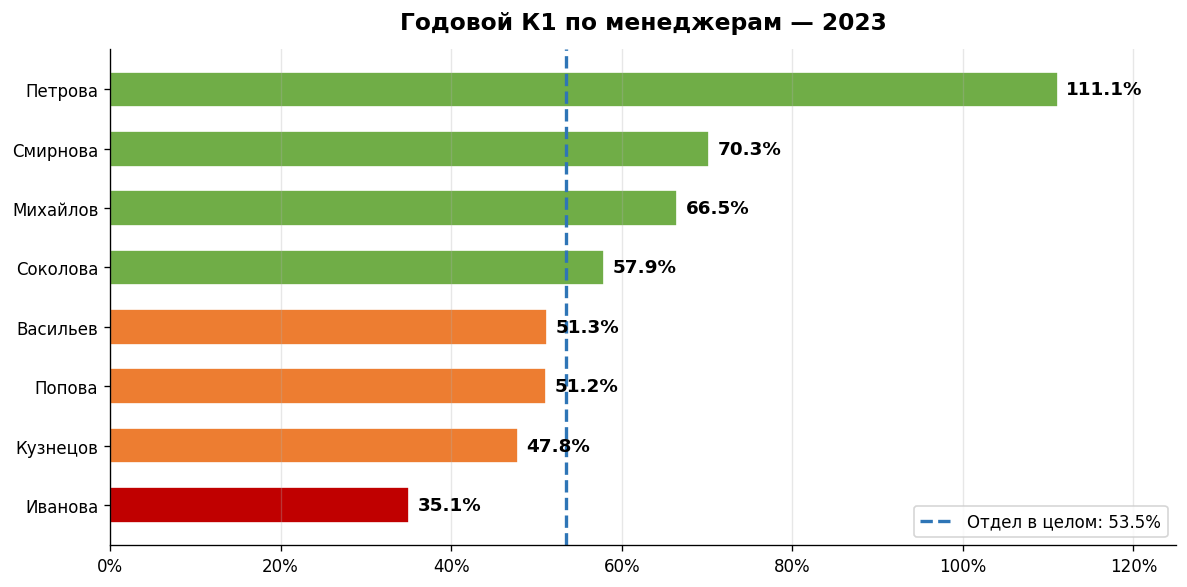

In [17]:
#Годовой К1 по менеджерам
mgr_k1_vals = [(mgr, annual[mgr]['coeff1']) for mgr in managers
               if isinstance(annual[mgr]['coeff1'], float) and not np.isnan(annual[mgr]['coeff1'])]
mgr_k1_vals.sort(key=lambda x: x[1])

dept_k1_annual = annual['Отдел в целом']['coeff1']

fig, ax = plt.subplots(figsize=(10, 5))
names = [m.split()[0] for m, _ in mgr_k1_vals]
vals  = [v for _, v in mgr_k1_vals]
colors = ['#C00000' if v < 0.4 else '#ED7D31' if v < 0.55 else '#70AD47' for v in vals]

bars = ax.barh(names, vals, color=colors, edgecolor='white', height=0.6)
ax.axvline(dept_k1_annual, color='#2E75B6', linestyle='--', linewidth=2,
           label=f'Отдел в целом: {dept_k1_annual:.1%}')

for bar, val in zip(bars, vals):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=11, fontweight='bold')

ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlim(0, 1.25)
ax.set_title('Годовой К1 по менеджерам — 2023', fontsize=14, fontweight='bold', pad=12)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

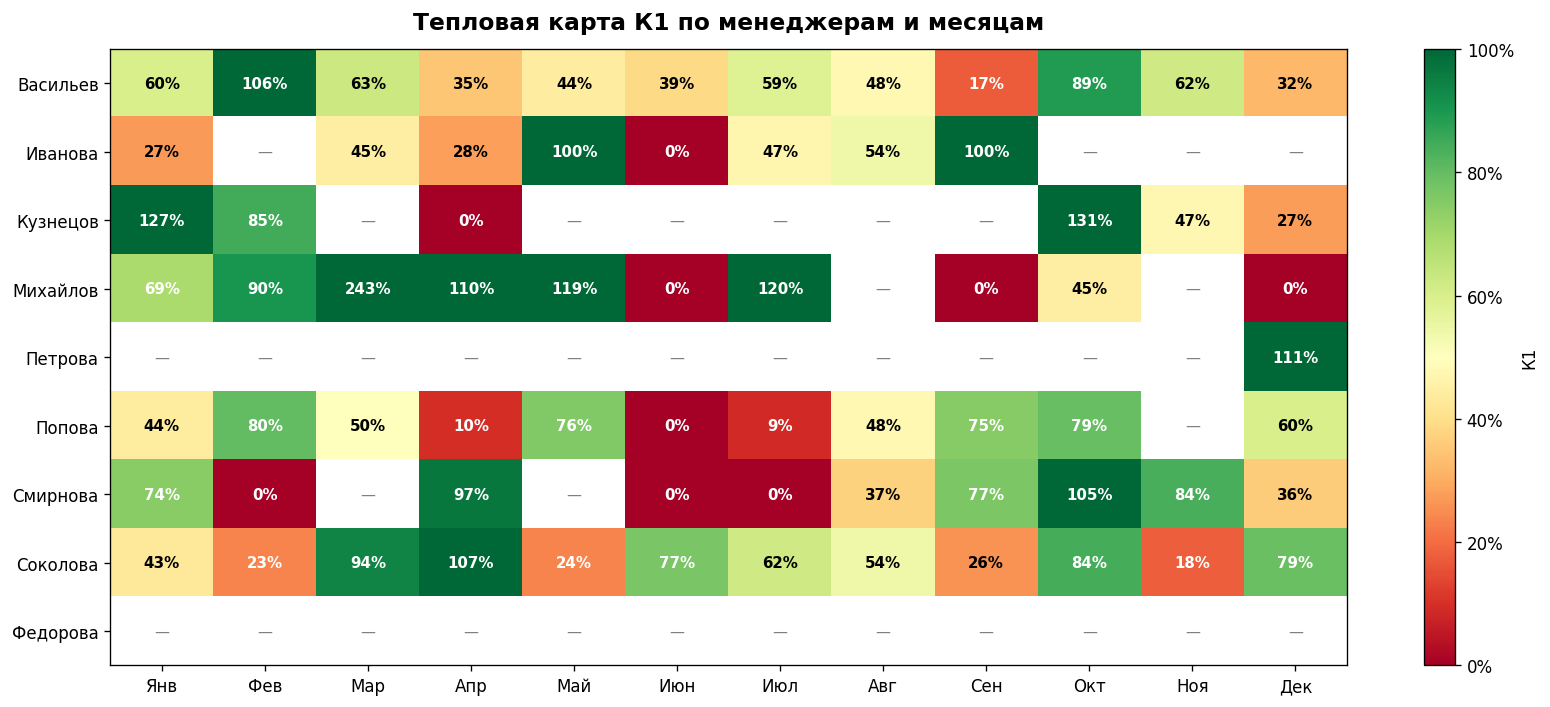

In [18]:
#Тепловая карта К1 по менеджерам и месяцам
import matplotlib.colors as mcolors

heat_data = df_k1.drop('Отдел в целом').drop(columns='Год')
heat_data.index = [n.split()[0] for n in heat_data.index]

fig, ax = plt.subplots(figsize=(14, 6))
cmap = plt.cm.RdYlGn
masked = np.ma.masked_invalid(heat_data.values.astype(float))
im = ax.imshow(masked, cmap=cmap, vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(short_months)))
ax.set_xticklabels(short_months, fontsize=10)
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels(heat_data.index, fontsize=10)

for i in range(len(heat_data)):
    for j in range(len(short_months)):
        val = heat_data.iloc[i, j]
        if not np.isnan(val):
            color = 'white' if val > 0.65 or val < 0.25 else 'black'
            ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold')
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=9, color='gray')

plt.colorbar(im, ax=ax, format=mticker.PercentFormatter(1.0), label='К1')
ax.set_title('Тепловая карта К1 по менеджерам и месяцам', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

---
## 7. Итоговые выводы

In [23]:
dept = annual['Отдел в целом']
print(f"Отдел в целом:")
print(f"   К1: {dept['coeff1']:.1%}")
print(f"   К2: {dept['coeff2']:.1%}")
print(f"   Общая база К1: {dept['c1_denom']:,.0f} руб.")
print(f"   Пролонгировано: {dept['c1_numer']:,.0f} руб.")

print("\nПо менеджерам (К1 годовой):")
mgr_sorted = sorted(managers,
    key=lambda m: annual[m]['coeff1'] if isinstance(annual[m]['coeff1'], float) and not np.isnan(annual[m]['coeff1']) else -1,
    reverse=True
)
for i, mgr in enumerate(mgr_sorted, 1):
    k1 = annual[mgr]['coeff1']
    k2 = annual[mgr]['coeff2']
    k1_str = f'{k1:.1%}' if isinstance(k1, float) and not np.isnan(k1) else 'н/д'
    k2_str = f'{k2:.1%}' if isinstance(k2, float) and not np.isnan(k2) else 'н/д'
    print(f"   {mgr:<32} К1={k1_str:<8} К2={k2_str}")

best_month_idx = np.nanargmax([results[m]['Отдел в целом']['coeff1'] for m in MONTHS_2023])
worst_month_idx = np.nanargmin([results[m]['Отдел в целом']['coeff1'] for m in MONTHS_2023])
print(f"\nЛучший месяц по К1:  {MONTHS_2023[best_month_idx]} ({results[MONTHS_2023[best_month_idx]]['Отдел в целом']['coeff1']:.1%})")
print(f"Худший месяц по К1:  {MONTHS_2023[worst_month_idx]} ({results[MONTHS_2023[worst_month_idx]]['Отдел в целом']['coeff1']:.1%})")


Отдел в целом:
   К1: 53.5%
   К2: 5.0%
   Общая база К1: 35,707,592 руб.
   Пролонгировано: 19,094,990 руб.

По менеджерам (К1 годовой):
   Петрова Анна Дмитриевна          К1=111.1%   К2=н/д
   Смирнова Ольга Владимировна      К1=70.3%    К2=25.4%
   Михайлов Андрей Сергеевич        К1=66.5%    К2=0.0%
   Соколова Анастасия Викторовна    К1=57.9%    К2=5.9%
   Васильев Артем Александрович     К1=51.3%    К2=6.3%
   Попова Екатерина Николаевна      К1=51.2%    К2=1.7%
   Кузнецов Михаил Иванович         К1=47.8%    К2=0.0%
   Иванова Мария Сергеевна          К1=35.1%    К2=0.0%
   Федорова Марина Васильевна       К1=н/д      К2=н/д

Лучший месяц по К1:  Октябрь 2023 (82.8%)
Худший месяц по К1:  Июнь 2023 (22.1%)


## 8. Экспорт результатов в Excel

Эта ячейка берёт уже посчитанные переменные (`results`, `annual`, `valid`) и записывает их в `.xlsx` файл с полным оформлением

In [24]:
!pip install openpyxl -q

import openpyxl
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

DARK_BLUE    = '1F3864'
MID_BLUE     = '2E75B6'
LIGHT_BLUE   = 'BDD7EE'
LIGHTER_BLUE = 'DEEAF1'
WHITE        = 'FFFFFF'
DARK_GRAY    = '404040'
MED_GRAY     = '808080'
LIGHT_GRAY   = 'F2F2F2'
GREEN_DARK   = '375623'
GREEN_MID    = '70AD47'
ORANGE       = 'ED7D31'

MONTHS_2023_SHORT = ['Янв','Фев','Мар','Апр','Май','Июн',
                     'Июл','Авг','Сен','Окт','Ноя','Дек']
all_entities = ['Отдел в целом'] + managers

def thin_border():
    s = Side(style='thin')
    return Border(left=s, right=s, top=s, bottom=s)

def write_header(ws, cell_ref, text, bg=DARK_BLUE, fg=WHITE,
                 bold=True, size=10, align='center', wrap=False):
    #Записывает заголовочную ячейку с заливкой и рамкой
    c = ws[cell_ref]
    c.value = text
    c.font      = Font(name='Calibri', bold=bold, color=fg, size=size)
    c.fill      = PatternFill('solid', start_color=bg)
    c.alignment = Alignment(horizontal=align, vertical='center',
                            wrap_text=wrap, indent=1 if align=='left' else 0)
    c.border    = thin_border()

def write_pct(ws, cell_ref, value, thresholds=(0.3, 0.5, 0.7)):
    #Записывает процентное значение с цветовой заливкой
    c = ws[cell_ref]
    if value is None or (isinstance(value, float) and np.isnan(value)):
        c.value = '—'
        bg = 'D9D9D9'
        fg = MED_GRAY
    else:
        c.value = value
        c.number_format = '0.0%'
        if   value < thresholds[0]: bg, fg = 'FFCCCC', DARK_GRAY
        elif value < thresholds[1]: bg, fg = 'FFEB9C', DARK_GRAY
        elif value < thresholds[2]: bg, fg = 'C6EFCE', DARK_GRAY
        else: bg, fg = GREEN_MID, WHITE
    c.font      = Font(name='Calibri', bold=True, color=fg, size=10)
    c.fill      = PatternFill('solid', start_color=bg)
    c.alignment = Alignment(horizontal='center', vertical='center')
    c.border    = thin_border()

def write_value(ws, cell_ref, value, fmt=None, bg=None,
                bold=False, align='center', fg=DARK_GRAY):
    #Записывает обычную ячейку
    c = ws[cell_ref]
    c.value     = value
    c.font      = Font(name='Calibri', bold=bold, color=fg, size=10)
    c.fill      = PatternFill('solid', start_color=bg or WHITE)
    c.alignment = Alignment(horizontal=align, vertical='center',
                            indent=1 if align=='left' else 0)
    c.border    = thin_border()
    if fmt:
        c.number_format = fmt

Сводный отчёт (К1 и К2 по менеджерам и месяцам)

In [25]:
wb = Workbook()
ws1 = wb.active
ws1.title = 'Сводный отчёт'
ws1.sheet_view.showGridLines = False
ws1.sheet_properties.tabColor = DARK_BLUE

ws1.column_dimensions['A'].width = 30
for col_letter in [get_column_letter(i) for i in range(2, 15)]:
    ws1.column_dimensions[col_letter].width = 8.5
ws1.column_dimensions['O'].width = 11
ws1.column_dimensions['P'].width = 8

# Заголовок
ws1.row_dimensions[1].height = 45
ws1.merge_cells('A1:P1')
c = ws1['A1']
c.value = 'ОТЧЁТ О ПРОЛОНГАЦИЯХ ДОГОВОРОВ — 2023 ГОД'
c.font      = Font(name='Calibri', bold=True, size=18, color=WHITE)
c.fill      = PatternFill('solid', start_color=DARK_BLUE)
c.alignment = Alignment(horizontal='center', vertical='center')

ws1.row_dimensions[2].height = 20
ws1.merge_cells('A2:P2')
c = ws1['A2']
c.value = 'Отдел сопровождения клиентов • Аналитический отчёт'
c.font      = Font(name='Calibri', size=11, color=WHITE, italic=True)
c.fill      = PatternFill('solid', start_color=MID_BLUE)
c.alignment = Alignment(horizontal='center', vertical='center')

#Секция К1
ws1.row_dimensions[3].height = 8
ws1.merge_cells('A3:P3')
ws1['A3'].fill = PatternFill('solid', start_color=LIGHT_BLUE)

ws1.row_dimensions[4].height = 28
ws1.merge_cells('A4:P4')
c = ws1['A4']
c.value = 'КОЭФФИЦИЕНТ ПРОЛОНГАЦИИ В 1-Й МЕСЯЦ  (К1)'
c.font      = Font(name='Calibri', bold=True, size=12, color=WHITE)
c.fill      = PatternFill('solid', start_color=MID_BLUE)
c.alignment = Alignment(horizontal='left', vertical='center', indent=1)

ws1.row_dimensions[5].height = 18
ws1.merge_cells('A5:P5')
c = ws1['A5']
c.value = 'Отношение суммы отгрузки пролонгированных проектов в 1-й месяц к сумме отгрузки завершившихся в предыдущем месяце'
c.font      = Font(name='Calibri', size=9, color=MED_GRAY, italic=True)
c.fill      = PatternFill('solid', start_color=LIGHTER_BLUE)
c.alignment = Alignment(horizontal='left', vertical='center', indent=1)

#Строка заголовков К1
ws1.row_dimensions[6].height = 25
write_header(ws1, 'A6', 'Менеджер', align='left')
for i, ms in enumerate(MONTHS_2023_SHORT):
    write_header(ws1, f'{get_column_letter(2+i)}6', ms)
write_header(ws1, 'O6', '2023\nГОД', wrap=True)
write_header(ws1, 'P6', 'РАНГ')

#Данные К1
for row_i, entity in enumerate(all_entities):
    r = 7 + row_i
    ws1.row_dimensions[r].height = 20
    is_dept = entity == 'Отдел в целом'
    bg = LIGHT_BLUE if is_dept else (LIGHT_GRAY if r % 2 == 0 else WHITE)

    c = ws1.cell(row=r, column=1)
    c.value     = entity
    c.font      = Font(name='Calibri', bold=is_dept, size=10, color=DARK_GRAY)
    c.fill      = PatternFill('solid', start_color=bg)
    c.alignment = Alignment(horizontal='left', vertical='center', indent=1)
    c.border    = thin_border()

    for col_i, m in enumerate(MONTHS_2023):
        val = results[m][entity]['coeff1'] if results[m].get(entity) else np.nan
        write_pct(ws1, f'{get_column_letter(2+col_i)}{r}', val)

    write_pct(ws1, f'O{r}', annual[entity]['coeff1'])  # годовой

    #Ранг
    c = ws1.cell(row=r, column=16)
    c.fill      = PatternFill('solid', start_color=bg)
    c.alignment = Alignment(horizontal='center', vertical='center')
    c.border    = thin_border()
    c.font      = Font(name='Calibri', size=10)


mgr_k1 = sorted(managers,
    key=lambda m: annual[m]['coeff1'] if isinstance(annual[m]['coeff1'], float) and not np.isnan(annual[m]['coeff1']) else -1,
    reverse=True)
ranks_k1 = {mgr: i+1 for i, mgr in enumerate(mgr_k1)}
for row_i, entity in enumerate(all_entities):
    if entity != 'Отдел в целом':
        r = 7 + row_i
        rank = ranks_k1[entity]
        c = ws1.cell(row=r, column=16)
        c.value = rank
        c.font  = Font(name='Calibri', bold=(rank <= 3), size=10,
                       color='C00000' if rank <= 3 else DARK_GRAY)

sep = 7 + len(all_entities)
ws1.row_dimensions[sep].height = 10
for col in range(1, 17):
    ws1.cell(row=sep, column=col).fill = PatternFill('solid', start_color='F2F2F2')

#Секция К2
r2_start = sep + 1
ws1.row_dimensions[r2_start].height = 28
ws1.merge_cells(f'A{r2_start}:P{r2_start}')
c = ws1[f'A{r2_start}']
c.value = 'КОЭФФИЦИЕНТ ПРОЛОНГАЦИИ ВО 2-Й МЕСЯЦ  (К2)'
c.font      = Font(name='Calibri', bold=True, size=12, color=WHITE)
c.fill      = PatternFill('solid', start_color=GREEN_DARK)
c.alignment = Alignment(horizontal='left', vertical='center', indent=1)

ws1.row_dimensions[r2_start+1].height = 25
write_header(ws1, f'A{r2_start+1}', 'Менеджер', bg=GREEN_DARK, align='left')
for i, ms in enumerate(MONTHS_2023_SHORT):
    write_header(ws1, f'{get_column_letter(2+i)}{r2_start+1}', ms, bg=GREEN_DARK)
write_header(ws1, f'O{r2_start+1}', '2023\nГОД', bg=GREEN_DARK, wrap=True)
write_header(ws1, f'P{r2_start+1}', 'РАНГ', bg=GREEN_DARK)

for row_i, entity in enumerate(all_entities):
    r = r2_start + 2 + row_i
    ws1.row_dimensions[r].height = 20
    is_dept = entity == 'Отдел в целом'
    bg = 'E2EFDA' if is_dept else (LIGHT_GRAY if r % 2 == 0 else WHITE)

    c = ws1.cell(row=r, column=1)
    c.value     = entity
    c.font      = Font(name='Calibri', bold=is_dept, size=10, color=DARK_GRAY)
    c.fill      = PatternFill('solid', start_color=bg)
    c.alignment = Alignment(horizontal='left', vertical='center', indent=1)
    c.border    = thin_border()

    for col_i, m in enumerate(MONTHS_2023):
        val = results[m][entity]['coeff2'] if results[m].get(entity) else np.nan
        write_pct(ws1, f'{get_column_letter(2+col_i)}{r}', val, thresholds=(0.05, 0.1, 0.2))

    write_pct(ws1, f'O{r}', annual[entity]['coeff2'], thresholds=(0.05, 0.1, 0.2))

    c = ws1.cell(row=r, column=16)
    c.fill   = PatternFill('solid', start_color=bg)
    c.border = thin_border()
    c.font   = Font(name='Calibri', size=10)
    c.alignment = Alignment(horizontal='center', vertical='center')

#Ранги К2
mgr_k2 = sorted(managers,
    key=lambda m: annual[m]['coeff2'] if isinstance(annual[m]['coeff2'], float) and not np.isnan(annual[m]['coeff2']) else -1,
    reverse=True)
ranks_k2 = {mgr: i+1 for i, mgr in enumerate(mgr_k2)}
for row_i, entity in enumerate(all_entities):
    if entity != 'Отдел в целом':
        r = r2_start + 2 + row_i
        rank = ranks_k2[entity]
        c = ws1.cell(row=r, column=16)
        c.value = rank
        c.font  = Font(name='Calibri', bold=(rank <= 3), size=10,
                       color=GREEN_DARK if rank <= 3 else DARK_GRAY)

Детализация по менеджерам (годовые показатели)

In [26]:
ws2 = wb.create_sheet('Детализация по менеджерам')
ws2.sheet_view.showGridLines = False
ws2.sheet_properties.tabColor = MID_BLUE

col_widths = [28, 12, 12, 16, 16, 16, 16]
for i, w in enumerate(col_widths):
    ws2.column_dimensions[get_column_letter(i+1)].width = w

ws2.row_dimensions[1].height = 40
ws2.merge_cells('A1:G1')
c = ws2['A1']
c.value = 'ДЕТАЛИЗАЦИЯ ПО МЕНЕДЖЕРАМ — ГОДОВЫЕ ПОКАЗАТЕЛИ 2023'
c.font      = Font(name='Calibri', bold=True, size=15, color=WHITE)
c.fill      = PatternFill('solid', start_color=DARK_BLUE)
c.alignment = Alignment(horizontal='center', vertical='center')

ws2.row_dimensions[2].height = 30
headers2 = ['Менеджер', 'К1 (год)', 'К2 (год)',
            'База К1 (руб.)', 'Пролонг К1 (руб.)',
            'База К2 (руб.)', 'Пролонг К2 (руб.)']
for j, h in enumerate(headers2):
    write_header(ws2, f'{get_column_letter(j+1)}2', h, bg=MID_BLUE, wrap=True,
                 align='left' if j == 0 else 'center')

for row_i, entity in enumerate(all_entities):
    r = 3 + row_i
    ws2.row_dimensions[r].height = 20
    is_dept = entity == 'Отдел в целом'
    bg = LIGHT_BLUE if is_dept else (LIGHT_GRAY if r % 2 == 0 else WHITE)
    a  = annual[entity]

    # Имя
    c = ws2.cell(row=r, column=1)
    c.value     = entity
    c.font      = Font(name='Calibri', bold=is_dept, size=10, color=DARK_GRAY)
    c.fill      = PatternFill('solid', start_color=bg)
    c.alignment = Alignment(horizontal='left', vertical='center', indent=1)
    c.border    = thin_border()

    # К1 и К2 с цветом
    write_pct(ws2, f'B{r}', a['coeff1'])
    write_pct(ws2, f'C{r}', a['coeff2'], thresholds=(0.05, 0.1, 0.2))

    # Числовые базы
    for col_i, key in enumerate(['c1_denom','c1_numer','c2_denom','c2_numer'], start=4):
        write_value(ws2, f'{get_column_letter(col_i)}{r}',
                    a[key], fmt='#,##0', bg=bg, align='right', bold=is_dept)


Помесячная динамика (отдел в целом)

In [27]:
ws3 = wb.create_sheet('Помесячная динамика')
ws3.sheet_view.showGridLines = False
ws3.sheet_properties.tabColor = GREEN_MID

for i, w in enumerate([18, 10, 10, 18, 18, 18, 18]):
    ws3.column_dimensions[get_column_letter(i+1)].width = w

ws3.row_dimensions[1].height = 40
ws3.merge_cells('A1:G1')
c = ws3['A1']
c.value = 'ПОМЕСЯЧНАЯ ДИНАМИКА ПРОЛОНГАЦИЙ — ОТДЕЛ В ЦЕЛОМ — 2023'
c.font      = Font(name='Calibri', bold=True, size=14, color=WHITE)
c.fill      = PatternFill('solid', start_color=DARK_BLUE)
c.alignment = Alignment(horizontal='center', vertical='center')

headers3 = ['Месяц', 'К1', 'К2',
            'База К1 (руб.)', 'Пролонг К1 (руб.)',
            'База К2 (руб.)', 'Пролонг К2 (руб.)']
ws3.row_dimensions[2].height = 25
for j, h in enumerate(headers3):
    write_header(ws3, f'{get_column_letter(j+1)}2', h, bg=MID_BLUE,
                 align='left' if j == 0 else 'center')

for i, m in enumerate(MONTHS_2023):
    r   = 3 + i
    res = results[m]['Отдел в целом']
    bg  = LIGHT_GRAY if r % 2 == 0 else WHITE
    ws3.row_dimensions[r].height = 20

    write_value(ws3, f'A{r}', m,                   bg=bg, align='left')
    write_pct(ws3,   f'B{r}', res['coeff1'])
    write_pct(ws3,   f'C{r}', res['coeff2'],        thresholds=(0.05, 0.1, 0.2))
    write_value(ws3, f'D{r}', res['c1_denom'],      fmt='#,##0', bg=bg, align='right')
    write_value(ws3, f'E{r}', res['c1_numer'],      fmt='#,##0', bg=bg, align='right')
    write_value(ws3, f'F{r}', res['c2_denom'],      fmt='#,##0', bg=bg, align='right')
    write_value(ws3, f'G{r}', res['c2_numer'],      fmt='#,##0', bg=bg, align='right')

# Итоговая строка
r_tot = 3 + len(MONTHS_2023)
ws3.row_dimensions[r_tot].height = 22
a = annual['Отдел в целом']
tot_data = ['Итого 2023', a['coeff1'], a['coeff2'],
            a['c1_denom'], a['c1_numer'], a['c2_denom'], a['c2_numer']]
for j, val in enumerate(tot_data):
    c = ws3.cell(row=r_tot, column=j+1)
    c.value     = val
    c.font      = Font(name='Calibri', bold=True, size=11, color=WHITE)
    c.fill      = PatternFill('solid', start_color=DARK_BLUE)
    c.alignment = Alignment(horizontal='right' if j > 0 else 'left',
                            vertical='center', indent=1 if j == 0 else 0)
    c.border    = thin_border()
    if j == 1: c.number_format = '0.0%'
    if j == 2: c.number_format = '0.0%'
    if j >= 3: c.number_format = '#,##0'

Методология

In [28]:
ws4 = wb.create_sheet('Методология')
ws4.sheet_view.showGridLines = False
ws4.sheet_properties.tabColor = 'A9D18E'
ws4.column_dimensions['A'].width = 4
ws4.column_dimensions['B'].width = 70

ws4.row_dimensions[1].height = 45
ws4.merge_cells('A1:B1')
c = ws4['A1']
c.value = 'МЕТОДОЛОГИЯ РАСЧЁТА КОЭФФИЦИЕНТОВ ПРОЛОНГАЦИИ'
c.font      = Font(name='Calibri', bold=True, size=15, color=WHITE)
c.fill      = PatternFill('solid', start_color=DARK_BLUE)
c.alignment = Alignment(horizontal='center', vertical='center')

method_content = [
    (MID_BLUE,    WHITE,     True,  13, 'ОПРЕДЕЛЕНИЯ'),
    (LIGHTER_BLUE, DARK_GRAY, False, 10, 'Пролонгация — возобновление договора после завершения предыдущего периода.'),
    (LIGHTER_BLUE, DARK_GRAY, False, 10, 'Коэффициент пролонгации — доля суммы отгрузки по пролонгированным договорам от суммы завершившихся.'),
    (WHITE, WHITE, False, 6, ''),
    (MID_BLUE,    WHITE,     True,  13, 'КОЭФФИЦИЕНТ К1 — ПРОЛОНГАЦИЯ В 1-Й МЕСЯЦ'),
    (WHITE, DARK_GRAY, False, 10, '  Знаменатель: сумма отгрузки последнего месяца проектов, завершившихся в месяце M-1'),
    (WHITE, DARK_GRAY, False, 10, '  Числитель: сумма отгрузки в месяце M по тем же проектам, у которых есть отгрузка в M'),
    (LIGHTER_BLUE, DARK_GRAY, True,  10, '  К1 = Σ(отгрузка[M] пролонгированных) / Σ(отгрузка[M-1] всех завершившихся)'),
    (WHITE, WHITE, False, 6, ''),
    (GREEN_DARK,  WHITE,     True,  13, 'КОЭФФИЦИЕНТ К2 — ПРОЛОНГАЦИЯ ВО 2-Й МЕСЯЦ'),
    (WHITE, DARK_GRAY, False, 10, '  База: проекты из M-2, у которых НЕТ отгрузки в M-1 (не пролонгировались в 1-й месяц)'),
    (WHITE, DARK_GRAY, False, 10, '  Знаменатель: сумма отгрузки[M-2] проектов базы'),
    (WHITE, DARK_GRAY, False, 10, '  Числитель: сумма отгрузки[M] проектов базы, у которых есть отгрузка в M'),
    ('E2EFDA', DARK_GRAY, True,  10, '  К2 = Σ(отгрузка[M] из базы M-2) / Σ(отгрузка[M-2] всей базы)'),
    (WHITE, WHITE, False, 6, ''),
    (ORANGE,      WHITE,     True,  13, 'ПРАВИЛА ОБРАБОТКИ ДАННЫХ'),
    (WHITE, DARK_GRAY, False, 10, '  1. Статусы «стоп» и «end» — проект исключается из расчёта полностью.'),
    (WHITE, DARK_GRAY, False, 10, '  2. Значение «в ноль» — берётся отгрузка ближайшего предыдущего ненулевого месяца.'),
    (WHITE, DARK_GRAY, False, 10, '  3. Дубли строк: числовые значения суммируются; «стоп»/«end» приоритетнее чисел.'),
    (WHITE, DARK_GRAY, False, 10, '  4. АМ берётся из prolongations.csv — эти данные первичны.'),
    (WHITE, WHITE, False, 6, ''),
    (LIGHT_BLUE,  DARK_GRAY, True,  11, 'ГОДОВОЙ КОЭФФИЦИЕНТ'),
    (WHITE, DARK_GRAY, False, 10, '  Годовой К = Σ(все числители за 2023) / Σ(все знаменатели за 2023).'),
    (WHITE, DARK_GRAY, False, 10, '  Это взвешенное среднее — корректнее, чем среднее арифметическое месячных коэффициентов.'),
]

for row_i, (bg, fg, bold, size, text) in enumerate(method_content, start=2):
    ws4.row_dimensions[row_i].height = 18 if text else 6
    ws4.merge_cells(f'A{row_i}:B{row_i}')
    c = ws4[f'A{row_i}']
    c.value     = text
    c.font      = Font(name='Calibri', bold=bold, size=size, color=fg)
    c.fill      = PatternFill('solid', start_color=bg)
    c.alignment = Alignment(horizontal='left', vertical='center', indent=2)

Сохранение файла

In [30]:
OUTPUT_FILE = 'отчет.xlsx'
wb.save(OUTPUT_FILE)

from google.colab import files
files.download(OUTPUT_FILE)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>